<div class="alert alert-block alert-success">
    <h1 align="center">Traffic-Signs Detection | YOLO26</h1>
    <h3 align="center">Object Detection</h3>
    
<a href="https://www.kaggle.com/code/pkdarabi/traffic-signs-detection-using-yolov8/input?select=car">
About Dataset
    </a>
    <br />
    <a href="https://docs.ultralytics.com/models/yolo26#overview">
About YOLO26
    </a>
</div>

<img src="https://previews.123rf.com/images/grafner/grafner1606/grafner160600026/61038877-wide-background-collage-of-many-road-sign-illustration.jpg"/>

<div style="
    background-color:#e6f9e6;
    border-left:6px solid #4caf50;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <h2 style="text-align: center; color: #007400; margin-top: 0;">
        Welcome to the Notebook! 
    </h2>
    <p style="margin-bottom:10px;text-align:justify;">
This notebook demonstrates a comprehensive implementation of traffic sign detection and classification using the latest YOLOv26 model from Ultralytics. The project focuses on accurately detecting various traffic signs under diverse real-world conditions including different lighting, weather, and distances.We cover data exploration, model fine-tuning, performance evaluation, and inference, aiming to achieve high accuracy and efficient detection suitable for this domain.
    </p>
</div>








<div style="
    background-color:#e6f9e6;
    border-left:6px solid #4caf50;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        YOLOv26 Design Philosophy: Edge-First:
    </p>
    <p style="margin-bottom:10px;text-align:justify;">
While models like YOLOv12 focused on increasing accuracy through attention mechanisms, YOLOv26 follows a different path — prioritizing simplicity, efficiency, and real-world deployability on edge and low-power devices. Its core goal is to deliver a lightweight, fast, and reliable model that runs efficiently on everyday hardware such as mobile phones, embedded systems, and smart cameras, without sacrificing accuracy.
    </p>
<p style="font-weight:bold;margin-bottom:10px;">
        Key Innovations in YOLO26:
    </p>
    
<ul style="margin:0;padding-left:20px;text-align:justify;">
        <li>End-to-End NMS-Free Inference: Completely removes the traditional Non-Maximum Suppression (NMS) post-processing step, enabling true end-to-end detection with significantly lower latency (up to 43% faster CPU inference).
</li>
        <li>DFL-Free Regression: Eliminates Distribution Focal Loss (DFL) to simplify the detection head, improve exportability, and enhance compatibility with diverse hardware platforms (TensorRT, CoreML, TFLite, ONNX, etc.).
</li>
        <li>MuSGD Optimizer: Introduces a novel hybrid optimizer inspired by large language model training techniques, resulting in more stable, faster, and better-converging training.

</li>
        <li>ProgLoss + STAL: Combines Progressive Loss Balancing and Small-Target-Aware Label Assignment to notably improve detection performance, especially for small and distant objects.
    </ul>
        <p style="margin-bottom:10px;text-align:justify;">
These innovations make YOLOv26 one of the most efficient and deployment-friendly models in the YOLO family to date.
    </p>

</div>


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1. Install Ultralytics And Load yolo26n
    </p>
</div>

In [10]:
!pip install ultralytics --upgrade -qq
from ultralytics import YOLO
model = YOLO('yolo26n.pt')


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1.1 Import Required Libraries
    </p>
</div>

In [11]:
import os
from IPython.display import Video
from pathlib import Path
import yaml
import glob
from tqdm.notebook import trange, tqdm
import random
#---
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
#---
import warnings
warnings.filterwarnings('ignore')

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        2. Data Overview
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Visualizing Dataset Samples
         </li>
        </ul>
</div>

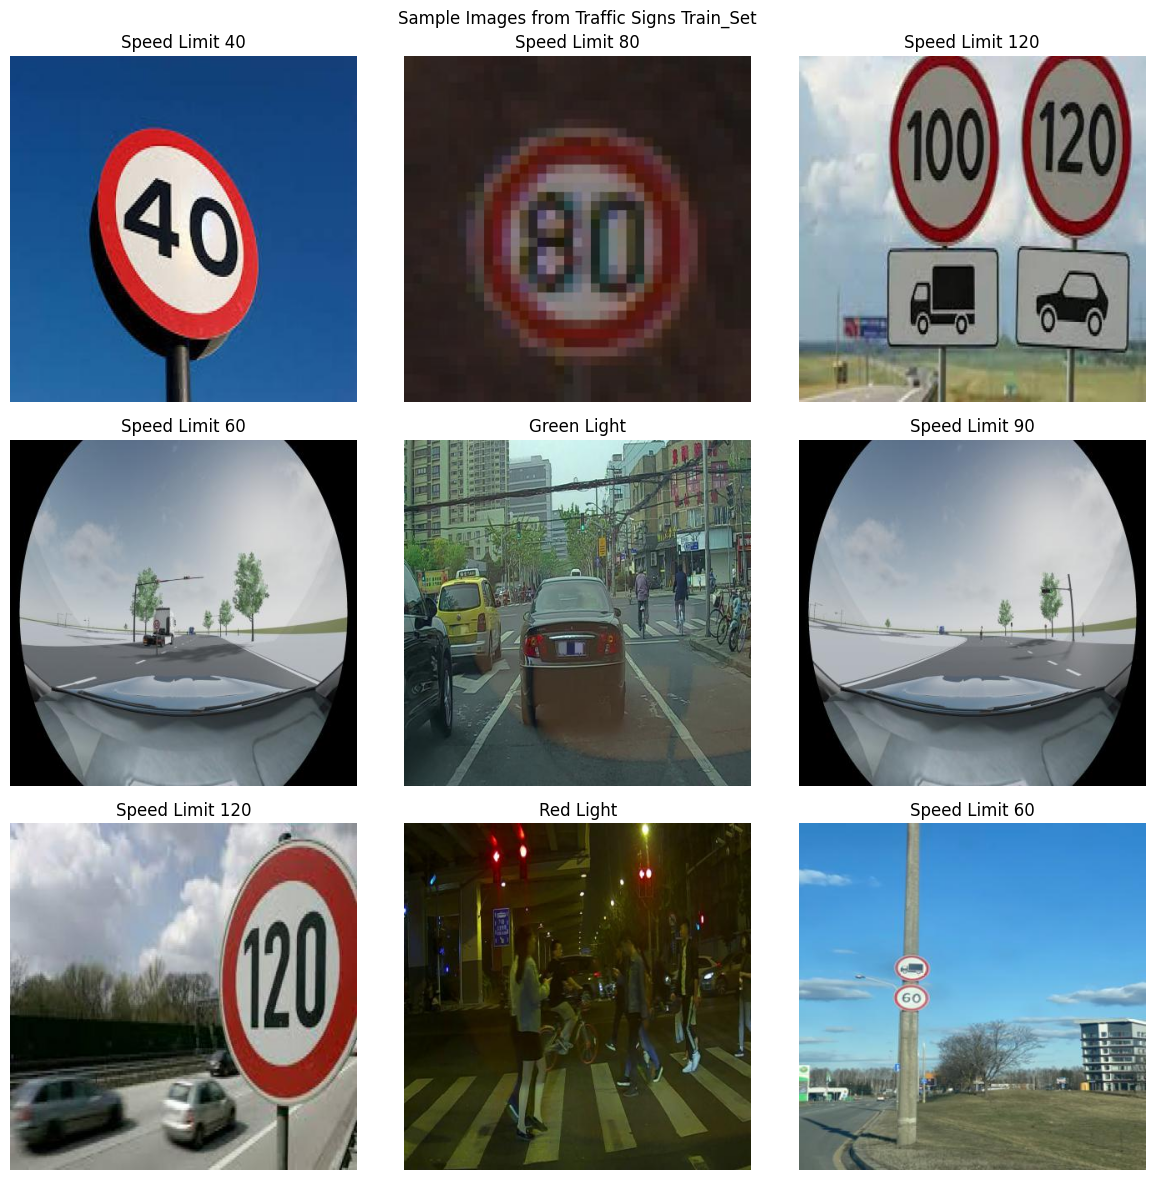

In [12]:
img_dir_train = Path("/kaggle/input/datasets/pkdarabi/cardetection/car/train/images")
label_dir_train = Path("/kaggle/input/datasets/pkdarabi/cardetection/car/train/labels")
#---
img_dir_val = Path("/kaggle/input/datasets/pkdarabi/cardetection/car/valid/images")
label_dir_val = Path("/kaggle/input/datasets/pkdarabi/cardetection/car/valid/labels")
#---
yaml_path = Path("/kaggle/input/datasets/pkdarabi/cardetection/car/data.yaml")

#---
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)
class_names = data['names']

#---
images = list(img_dir_train.glob("*.jpg"))
img_selected = random.sample(images, 9)
#---
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle("Sample Images from Traffic Signs Train_Set")

for ax, img_path in zip(axes.flatten(), img_selected):
    img = plt.imread(str(img_path))
    ax.imshow(img)
    label_file = label_dir_train / (img_path.stem + ".txt")
    with open(label_file) as f:
        cls_id = int(f.readline().split()[0])
        label = class_names[cls_id]
    
    ax.set_title(label, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Get Shape Of An Image For Using In Training Step
         </li>
        </ul>
</div>




In [13]:
for img_path in img_selected:
    image = cv2.imread(str(img_path))
    h, w, c = image.shape
    print(f"{img_path.name} → {w} x {h}  ({c} channels)")

000227_jpg.rf.740b5b8a5b19a6f910fdf1f838954fee.jpg → 416 x 416  (3 channels)
00005_00021_00013_png.rf.de596f6f3124d5108b49e7f4208bbbc8.jpg → 416 x 416  (3 channels)
001457_jpg.rf.fcec95a342bede13864154f05a092404.jpg → 416 x 416  (3 channels)
FisheyeCamera_1_00227_png.rf.db30b676091df2abb51c1020a614d20c.jpg → 416 x 416  (3 channels)
001069_jpg.rf.57e243fb810c7ae7a03e1b816b1f5a2a.jpg → 416 x 416  (3 channels)
FisheyeCamera_1_00264_png.rf.ce9af51bc252f41836019ba9b9a4b2cc.jpg → 416 x 416  (3 channels)
001459_jpg.rf.9272940ed50080bc6c5d1b7a0ed5e998.jpg → 416 x 416  (3 channels)
001042_jpg.rf.545beff2bbe5abec5feb037ea45529f6.jpg → 416 x 416  (3 channels)
road448_png.rf.be05c097d58df13cd840a93ed022cc0e.jpg → 416 x 416  (3 channels)


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Class Distribution Analysis
         </li>
        </ul>
</div>

In [15]:
def class_distribution(label_dir):
    all_classes = []
    
    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            for line in f:
                cls_id = int(line.split()[0])
                all_classes.append(cls_id)
    #---
    class_counts = pd.Series(all_classes).value_counts().sort_index()
    
    #---Create Dataframe
    df = pd.DataFrame({"Class_ID": class_counts.index,"Count": class_counts.values})
    class_dict = dict(enumerate(class_names))
    df = df.set_index(df["Class_ID"].map(class_dict))
    df.index.name = "Traffic Sign"
    df = df.sort_values("Count", ascending=False)
    #---
    display(df)
    
    #--- Plot
    plt.figure(figsize=(12,5))
    sns.barplot(x=df.index, y=df['Count'], palette='tab10')
    plt.xticks(rotation=90)
    plt.ylabel('Number of Object')
    plt.show


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Class Distribution - Train Set
         </li>
        </ul>
</div>

,Class_ID,Count
Traffic Sign,,
Red Light,1,585
Green Light,0,542
Speed Limit 30,7,334
Speed Limit 80,12,323
Speed Limit 70,11,318
Speed Limit 60,10,301
Speed Limit 20,6,285
Stop,14,285
Speed Limit 50,9,283


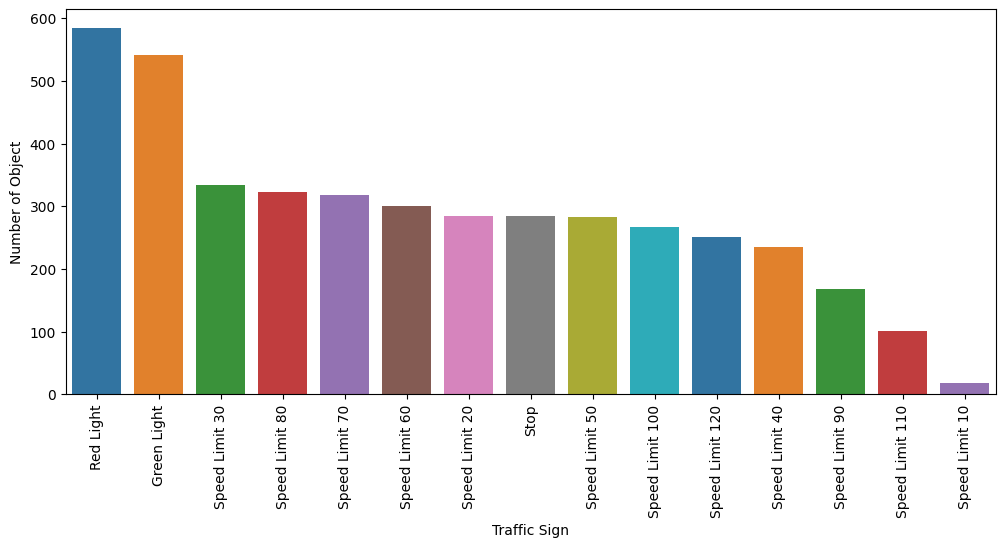

In [16]:
class_distribution(label_dir_train)

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Class Distribution - Validation Set
         </li>
        </ul>
</div>

,Class_ID,Count
Traffic Sign,,
Green Light,0,122
Red Light,1,108
Stop,14,81
Speed Limit 70,11,78
Speed Limit 60,10,76
Speed Limit 30,7,74
Speed Limit 50,9,71
Speed Limit 120,5,60
Speed Limit 20,6,56


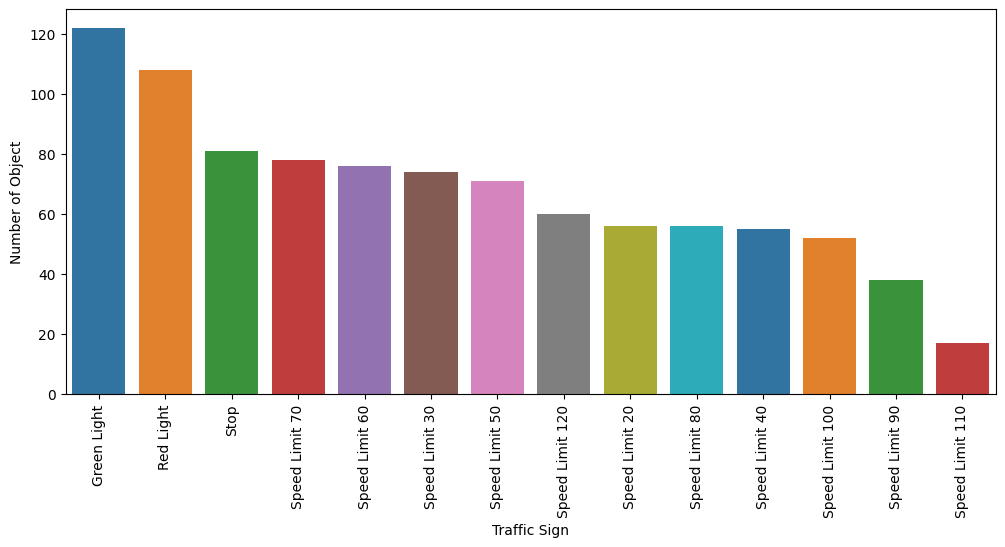

In [17]:
class_distribution(label_dir_val)

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
The dataset shows moderate class imbalance. Red Light and Green Light are the most frequent classes, while Speed Limit 10 has very few samples (only 19 instances in training). All classes exist in both training and validation sets.
        </li>
                <li>
Fortunately, YOLOv26 handles class imbalance effectively through its built-in Focal Loss and improved label assignment strategies. Therefore, manual class_weights is not recommended. Strong data augmentation on rare classes and sufficient training epochs will be more effective.
        </li>
    </ul>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Missing Images and Labels Check (Train And Validation)
         </li>
        </ul>
</div>

In [18]:
def missing_img_val(img_dir, label_dir):
    image_stems = {img.stem for img in img_dir.glob("*.jpg")}
    label_stems = {lbl.stem for lbl in label_dir.glob("*.txt")}
    
    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems
    
    print(f"Images without label : {len(missing_labels)}")
    print(f"Labels without image : {len(missing_images)}")

print('Missing Values For Train Set:')
missing_img_val(img_dir_train, label_dir_train)
print('-'*40)
print('Missing Values For Val Set:')
missing_img_val(img_dir_val, label_dir_val)

Missing Values For Train Set:
Images without label : 0
Labels without image : 0
----------------------------------------
Missing Values For Val Set:
Images without label : 0
Labels without image : 0


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        3. Training YOLOv26(yolo26n) Model
    </p>
</div>

In [ ]:
result = model.train(data=yaml_path,
                     epochs = 30,
                     batch = -1,
                     optimizer = 'auto',
                     imgsz=640,
                    verbose=False)

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Display Model Output Files
         </li>
        </ul>
</div>




In [19]:
output_model = '/kaggle/working/runs/detect/train'
print(os.listdir(output_model))

['val_batch0_pred.jpg', 'train_batch3080.jpg', 'val_batch2_labels.jpg', 'BoxPR_curve.png', 'labels.jpg', 'weights', 'BoxP_curve.png', 'val_batch0_labels.jpg', 'val_batch2_pred.jpg', 'train_batch3082.jpg', 'confusion_matrix.png', 'val_batch1_labels.jpg', 'confusion_matrix_normalized.png', 'BoxR_curve.png', 'train_batch0.jpg', 'val_batch1_pred.jpg', 'results.csv', 'train_batch1.jpg', 'BoxF1_curve.png', 'results.png', 'train_batch2.jpg', 'train_batch3081.jpg', 'args.yaml']


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Performance Evaluation Visualizations
         </li>
        </ul>
</div>

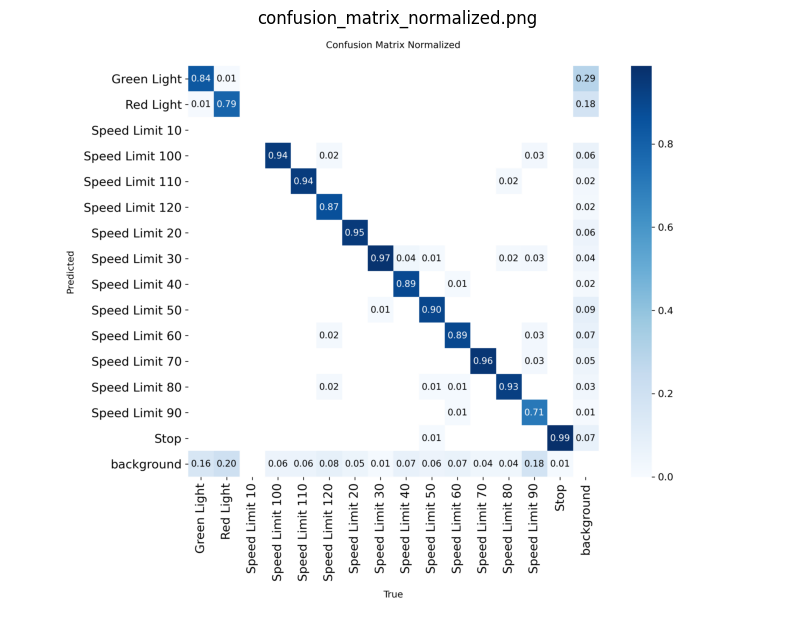

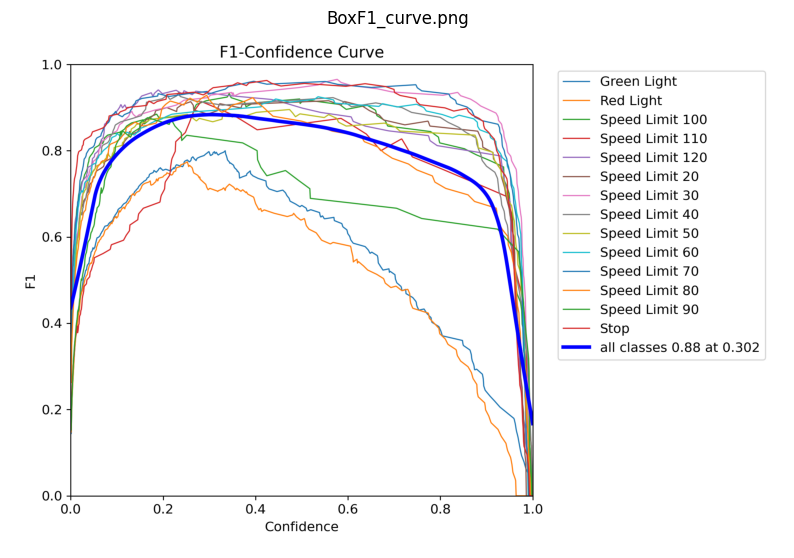

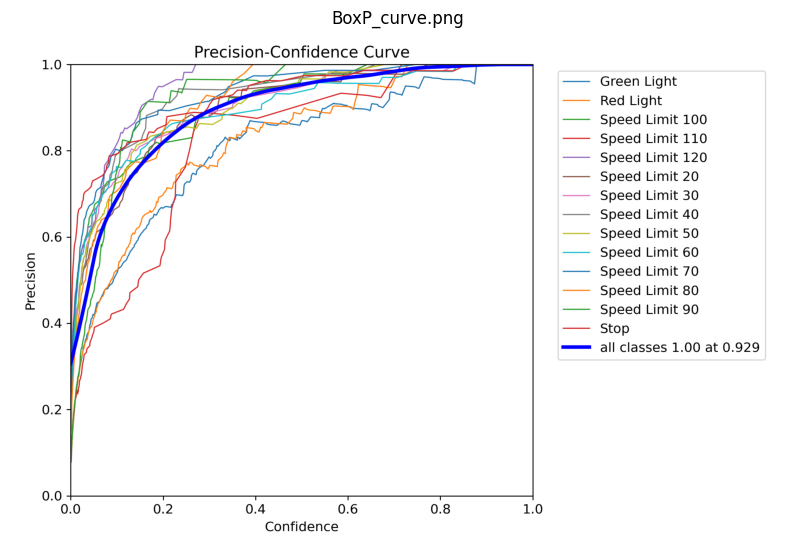

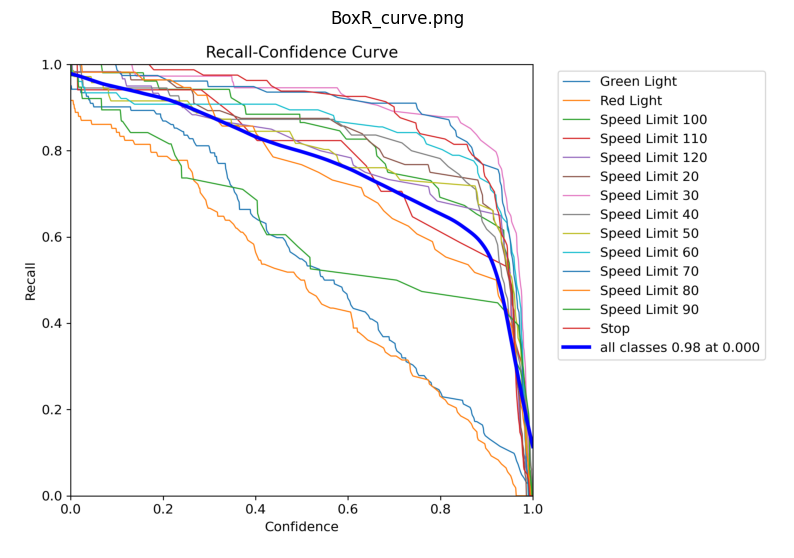

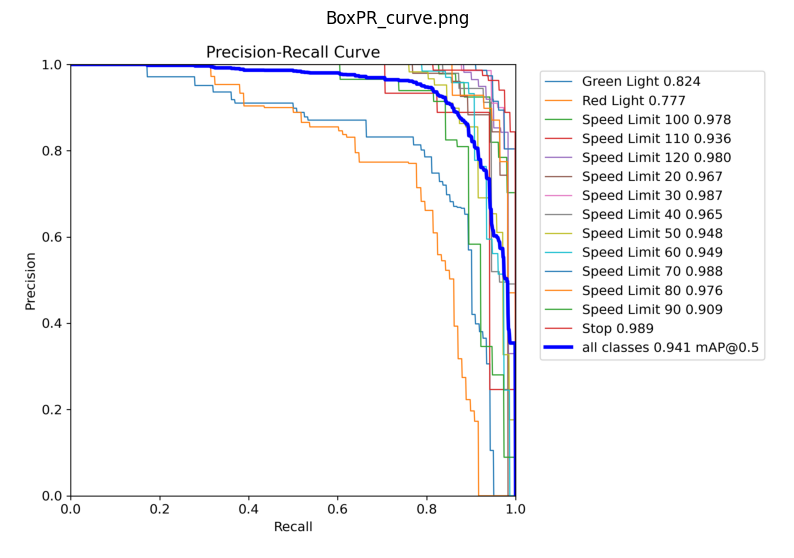

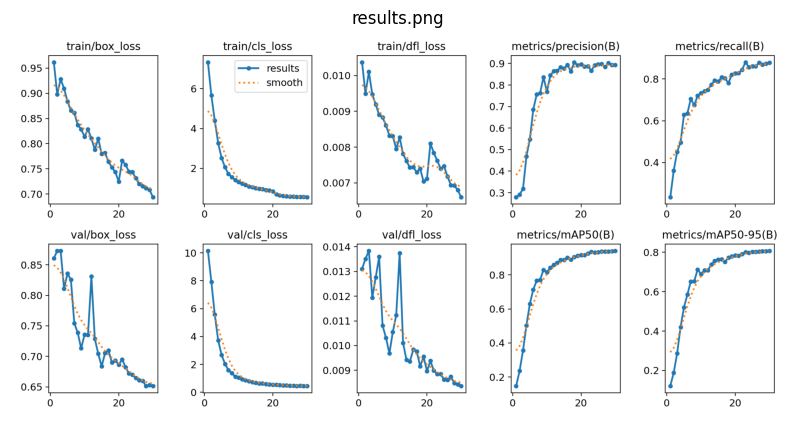

In [20]:
image_files = [
    'confusion_matrix_normalized.png',
    'BoxF1_curve.png',
    'BoxP_curve.png',
    'BoxR_curve.png',
    'BoxPR_curve.png',
    'results.png']

def display_images(post_training_files_path, image_files):
    for image_file in image_files:
        image_path = os.path.join(post_training_files_path, image_file)
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 10))
        plt.title(f'{image_file}')
        plt.imshow(img)
        plt.axis('off')
        plt.show()

display_images(output_model, image_files)

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
The results are quite good given the model's small size and limited training time. The precision-recall curve shows an mAP@0.5 of 0.941, meaning the model detects traffic signs with high accuracy at a 50% overlap threshold. The best F1 score is 0.88 at a confidence level of 0.302, indicating a good balance between precision and recall. The box loss curve also decreases steadily, showing successful learning. Considering this is the nano version with only 30 epochs, the performance is very respectable. To detect smaller or more challenging signs, a larger model (e.g., YOLOv8m) can be trained, or the number of epochs can be increased (e.g., to 100). Overall, this model is suitable for basic traffic sign detection tasks.
        </li>
    </ul>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Detailed Training Metrics (results.csv)
         </li>
        </ul>
</div>

In [21]:
df_result = pd.read_csv('/kaggle/working/runs/detect/train/results.csv')
df_result.tail(10)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
20,21,1074.44,0.76653,0.68636,0.00810,0.88541,0.82901,0.91707,0.78253,0.69485,0.53046,0.00938,0.000179,0.000179,0.000179
21,22,1122.81,0.75806,0.63857,0.00784,0.88753,0.84393,0.92551,0.79107,0.68235,0.51776,0.00899,0.000161,0.000161,0.000161
22,23,1170.79,0.74427,0.61607,0.00762,0.86678,0.88028,0.93584,0.80068,0.67179,0.48394,0.00885,0.000144,0.000144,0.000144
23,24,1219.06,0.74345,0.59043,0.00740,0.89220,0.85667,0.93256,0.79733,0.66972,0.48676,0.00885,0.000127,0.000127,0.000127
24,25,1267.10,0.73143,0.57679,0.00747,0.89625,0.86034,0.93422,0.80219,0.66442,0.46003,0.00863,0.000109,0.000109,0.000109
25,26,1315.28,0.71973,0.57223,0.00718,0.89810,0.86139,0.93661,0.80243,0.66078,0.45905,0.00862,0.000092,0.000092,0.000092
26,27,1363.61,0.71533,0.55727,0.00694,0.88340,0.87831,0.93718,0.80357,0.65990,0.45645,0.00874,0.000075,0.000075,0.000075
27,28,1411.68,0.71176,0.56255,0.00693,0.90153,0.86938,0.93762,0.80507,0.65156,0.45808,0.00848,0.000057,0.000057,0.000057
28,29,1459.68,0.70860,0.55598,0.00680,0.89289,0.87371,0.94003,0.80586,0.65283,0.45398,0.00843,0.000040,0.000040,0.000040
29,30,1507.34,0.69357,0.54385,0.00660,0.89367,0.87833,0.94105,0.80708,0.65158,0.45361,0.00837,0.000023,0.000023,0.000023


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Training Curves: Loss & Evaluation Metrics Over Epochs
         </li>
        </ul>
</div>

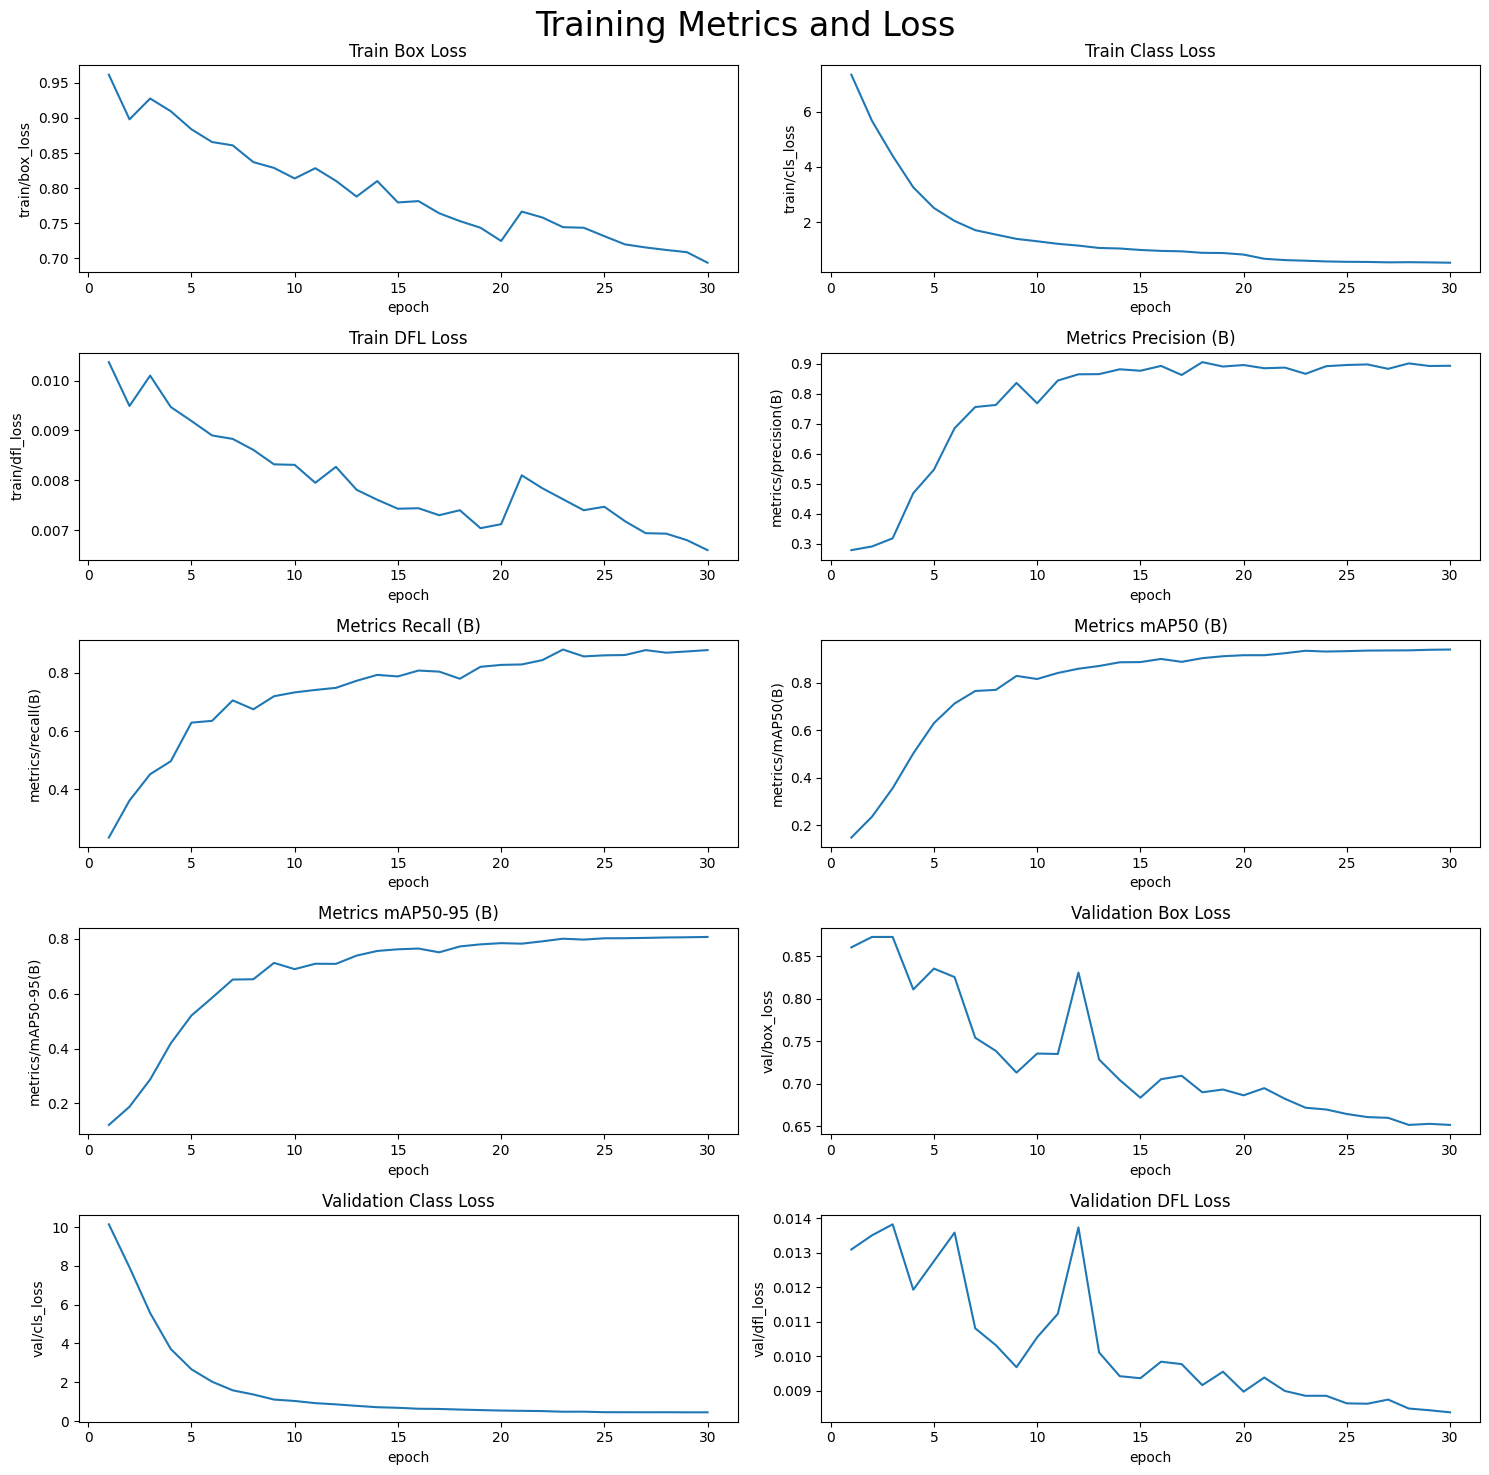

In [22]:
df_result.columns = df_result.columns.str.strip()

# Create subplots
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(15, 15))

# Plot the columns using seaborn
sns.lineplot(x='epoch', y='train/box_loss', data=df_result, ax=axs[0,0])
sns.lineplot(x='epoch', y='train/cls_loss', data=df_result, ax=axs[0,1])
sns.lineplot(x='epoch', y='train/dfl_loss', data=df_result, ax=axs[1,0])
sns.lineplot(x='epoch', y='metrics/precision(B)', data=df_result, ax=axs[1,1])
sns.lineplot(x='epoch', y='metrics/recall(B)', data=df_result, ax=axs[2,0])
sns.lineplot(x='epoch', y='metrics/mAP50(B)', data=df_result, ax=axs[2,1])
sns.lineplot(x='epoch', y='metrics/mAP50-95(B)', data=df_result, ax=axs[3,0])
sns.lineplot(x='epoch', y='val/box_loss', data=df_result, ax=axs[3,1])
sns.lineplot(x='epoch', y='val/cls_loss', data=df_result, ax=axs[4,0])
sns.lineplot(x='epoch', y='val/dfl_loss', data=df_result, ax=axs[4,1])

# Set titles and axis labels for each subplot
axs[0,0].set(title='Train Box Loss')
axs[0,1].set(title='Train Class Loss')
axs[1,0].set(title='Train DFL Loss')
axs[1,1].set(title='Metrics Precision (B)')
axs[2,0].set(title='Metrics Recall (B)')
axs[2,1].set(title='Metrics mAP50 (B)')
axs[3,0].set(title='Metrics mAP50-95 (B)')
axs[3,1].set(title='Validation Box Loss')
axs[4,0].set(title='Validation Class Loss')
axs[4,1].set(title='Validation DFL Loss')


plt.suptitle('Training Metrics and Loss', fontsize=24)
plt.subplots_adjust(top=0.8)
plt.tight_layout()
plt.show()

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
The training log over 30 epochs shows steady improvement in all key metrics. Both training and validation losses (box, class, and DFL) decrease consistently, starting from around 0.95 and dropping to about 0.75 by the final epoch. This indicates that the model is learning well without major overfitting. The precision metric improves gradually, and the mAP50 value reaches 0.94 at epoch 30, which is a strong result for a nano-sized model. The mAP50-95 also shows a clear upward trend, meaning the model performs reliably even at stricter IoU thresholds. Overall, the training process appears stable and the convergence is good. While 30 epochs are sufficient for basic traffic sign detection, more epochs or a larger model could further improve performance on challenging cases.
        </li>
    </ul>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
      Best Model Evaluation on Validation Set
         </li>
        </ul>
</div>

In [23]:
best_model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')
metrics = best_model.val(split = 'val')

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,377,761 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.7 ms, read: 39.2±10.4 MB/s, size: 20.1 KB)
val: Scanning /kaggle/input/datasets/pkdarabi/cardetection/car/valid/labels... 801 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 801/801 847.3it/s 0.9s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/pkdarabi/cardetection/car/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 7.3it/s 6.9s0.1s
                   all        801        944      0.894      0.878      0.941      0.808
           Green Light         87        122      0.789      0.797      0.824      0.501
             Red Light         74        108      0.757      0.657      0.777      0.469
       Speed Limit 100         52         52      0.895      0.942      

In [24]:
# Val Results 
print("precision(B): ", metrics.results_dict["metrics/precision(B)"])
print("metrics/recall(B): ", metrics.results_dict["metrics/recall(B)"])
print("metrics/mAP50(B): ", metrics.results_dict["metrics/mAP50(B)"])
print("metrics/mAP50-95(B): ", metrics.results_dict["metrics/mAP50-95(B)"])

precision(B):  0.8937148039384913
metrics/recall(B):  0.877972822192417
metrics/mAP50(B):  0.9409061839971938
metrics/mAP50-95(B):  0.8084913617241982


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
      Making Predictions On Test Images
         </li>
        </ul>
</div>

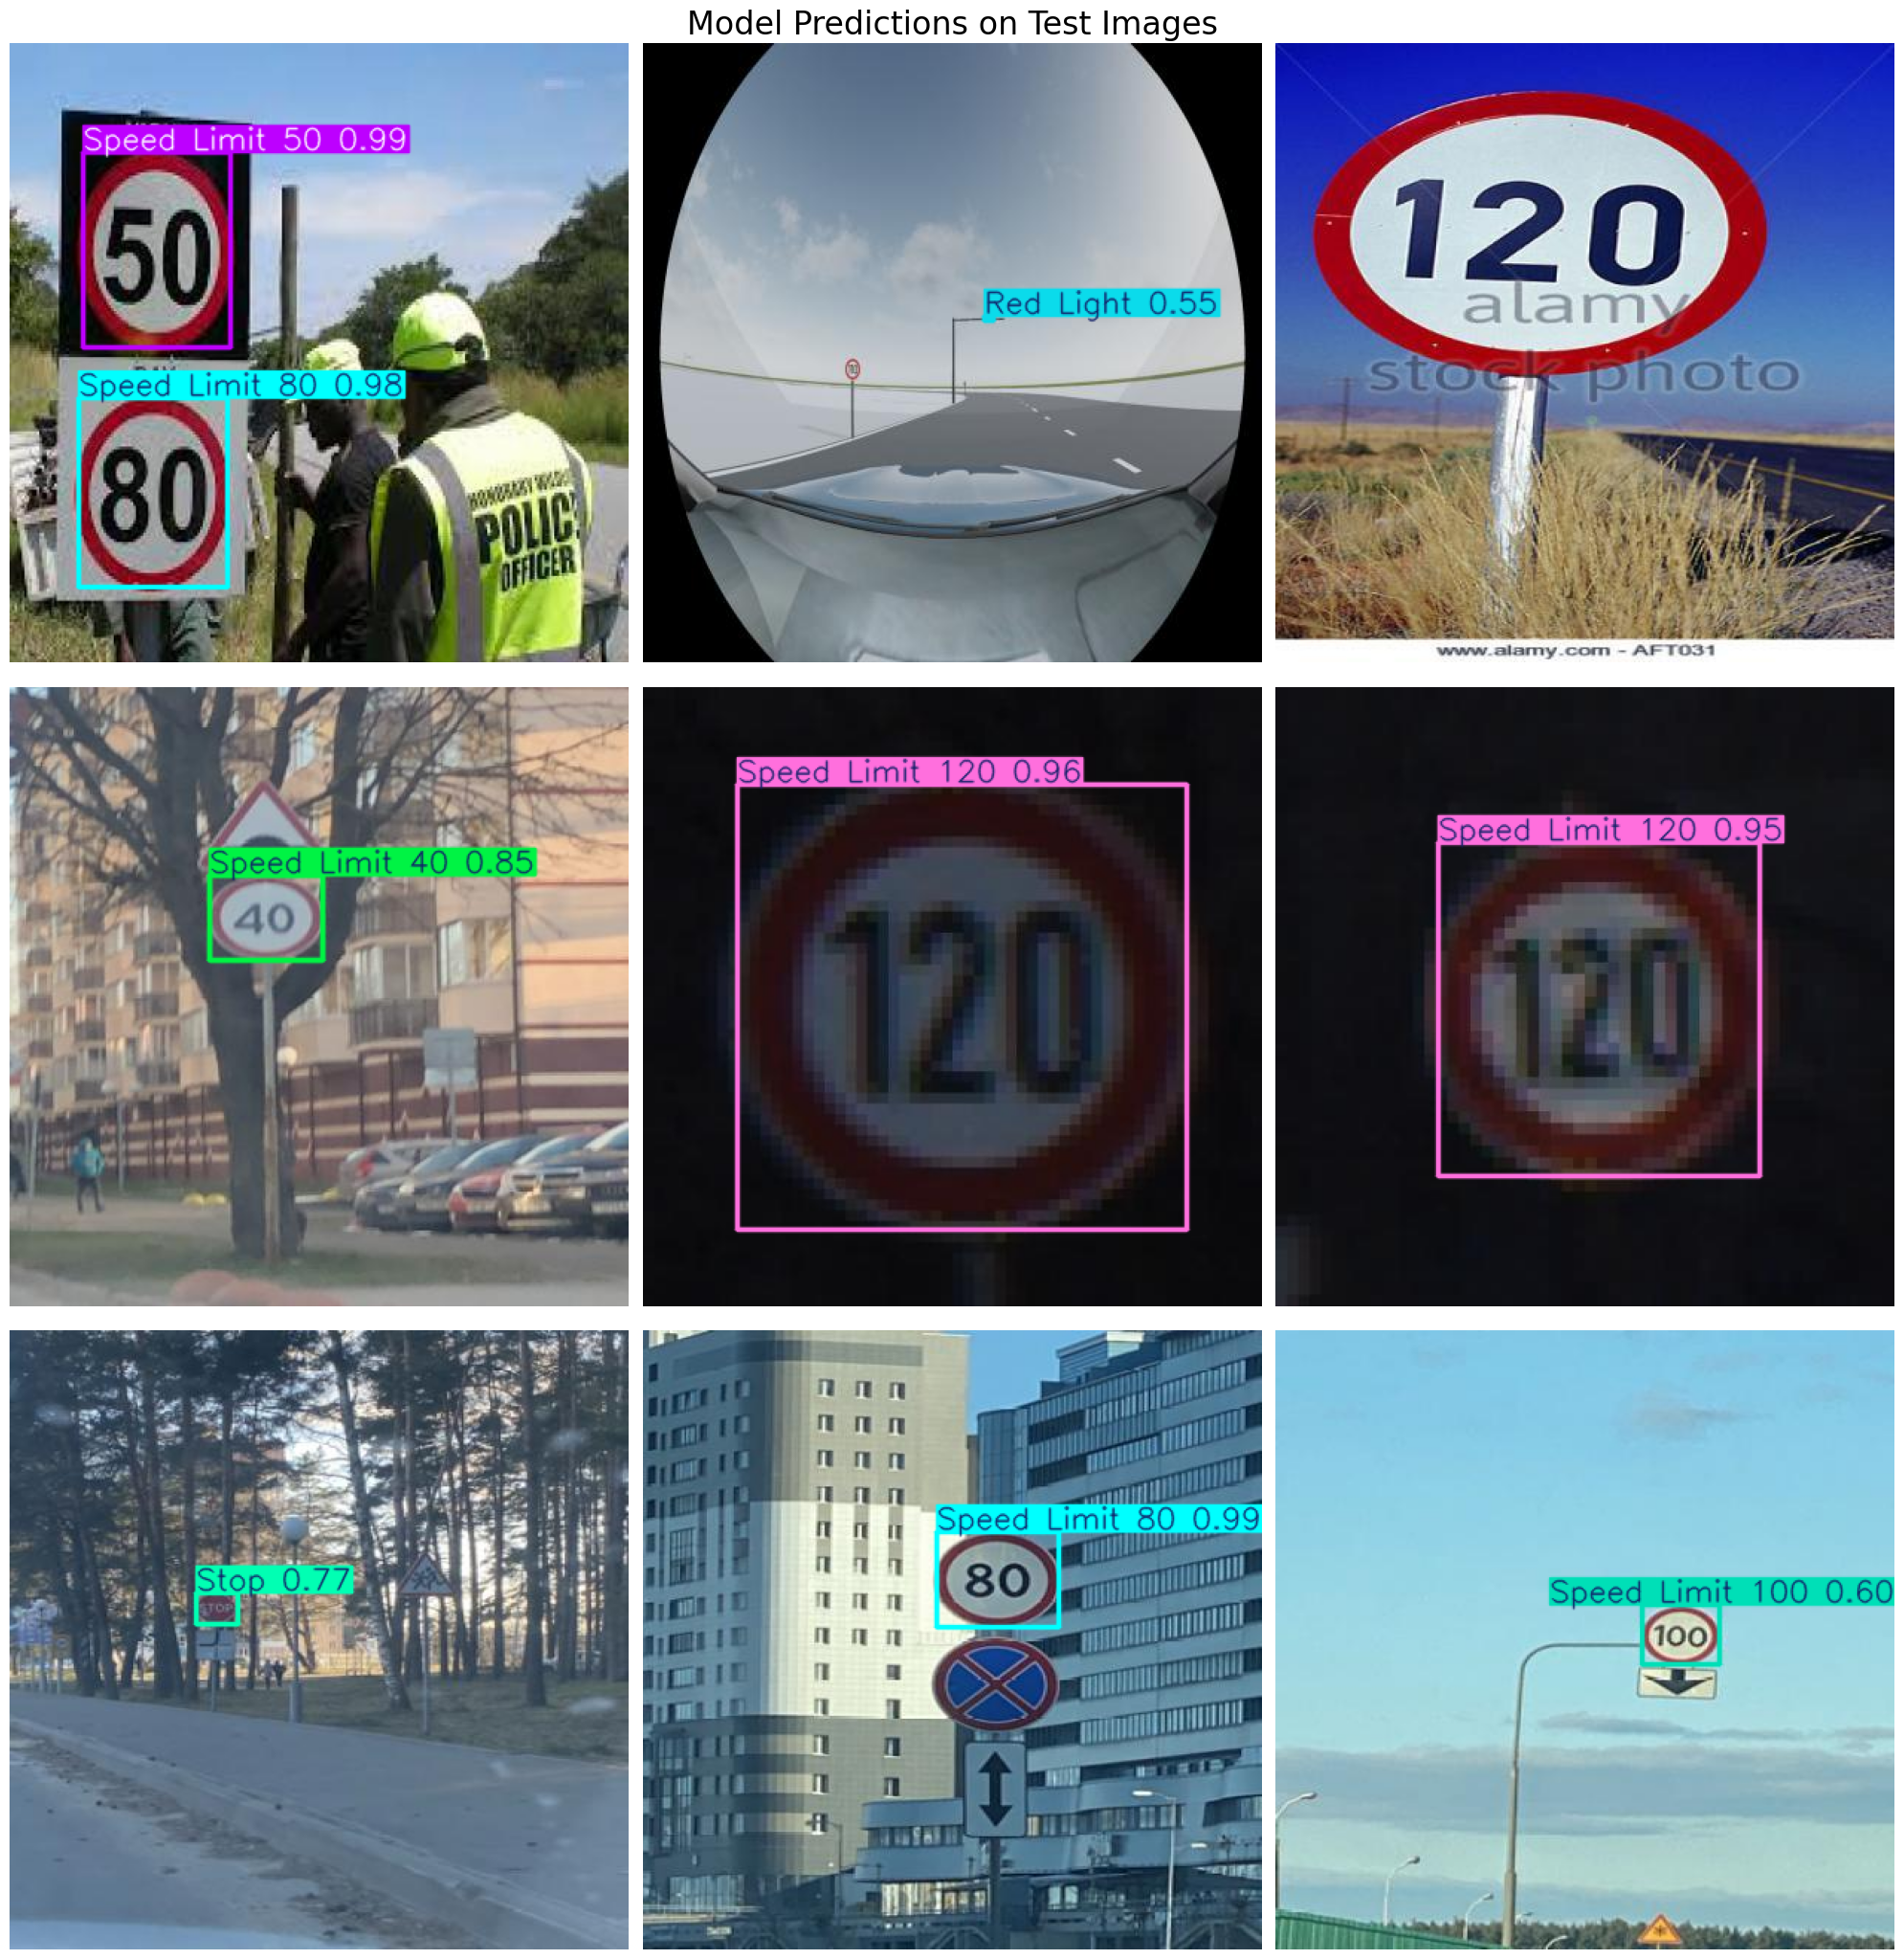

In [25]:
test_images_path = '/kaggle/input/datasets/pkdarabi/cardetection/car/test/images'
image_files = [f for f in os.listdir(test_images_path) if f.endswith('.jpg')]
#---
if len(image_files) > 0:
    # Select 9 Image 
    step = max(1, len(image_files) // 9)
    selected = [image_files[i] for i in range(0, len(image_files), step)][:9]

    # plot 3x3
    fig, axes = plt.subplots(3, 3, figsize=(20, 21))
    fig.suptitle('Model Predictions on Test Images', fontsize=24)

    for ax, img_file in zip(axes.flatten(), selected):
        img_path = os.path.join(test_images_path, img_file)
        img = cv2.imread(img_path)

        if img is not None:
            results = best_model.predict(source=img, imgsz=640, conf=0.3, verbose=False)
            #---
            annotated = results[0].plot(line_width=2)
            annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
            ax.imshow(annotated_rgb)
        else:
            ax.text(0.5, 0.5, 'Image load failed', ha='center', va='center')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('Images Not Found...!')

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        4. Traffic Sign Detection on Video Using Retrained YOLO Model
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
      Show Original Video Before Detect
         </li>
        </ul>
</div>

In [26]:
!ffmpeg -y -loglevel panic -i /kaggle/input/datasets/pkdarabi/cardetection/video.mp4 output.mp4
Video('output.mp4', width=600, height=300)

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
      Running YOLO Inference on Video (Save & Display)
         </li>
        </ul>
</div>

In [ ]:
# Use the YOLO model to detect signs
best_model.predict(source="/kaggle/input/datasets/pkdarabi/cardetection/video.mp4", show=False, save=True, verbose=False)


In [27]:
#---Display
!ffmpeg -y -loglevel panic -i /kaggle/working/runs/detect/predict/video.avi result_out.mp4
Video('result_out.mp4', width=600, height=300, embed=True)

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
      Save Model
         </li>
        </ul>
</div>

In [28]:
best_model.export(format='onnx')

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/kaggle/working/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.5s, saved as '/kaggle/working/runs/detect/train/weights/best.onnx' (9.4 MB)

Export complete (1.8s)
Results saved to /kaggle/working/runs/detect/train/weights/best.onnx
Predict:         yolo predict task=detect model=/kaggle/working/runs/detect/train/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/detect/train/weights/best.onnx imgsz=640 data=/kaggle/input/datasets/pkdarabi/cardetection/car/data.yaml  
Visualize:       https://netron.app


'/kaggle/working/runs/detect/train/weights/best.onnx'

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        Thanks a lot for going through this notebook! I hope it was helpful and worth your time.
    </p>
</div>